In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
%cd "C:/Users/mateo/Desktop/polymath-jr-drifting"
# This notebook uses DriftXpress; exact drift uses its separate loss/cache API in src.drift.
from src.driftXpress import *
from src.eval import (
    evaluate_latent_model,
    evaluate_generation,
    plot_conditional_mnist_results,
    plot_real_generated_projections,
    plot_loss_history,
    latent_statistics
)
from src.training import (
    compose_objective,
    format_epoch_losses,
    gradient_report,
    per_loss_gradient_norms,
    set_requires_grad,
)
torch.manual_seed(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


C:\Users\mateo\Desktop\polymath-jr-drifting
Using: cuda


In [2]:
transform = transforms.ToTensor()

SELECTED_DIGITS = (0, 8, 2, 4, 7, 9)
DIGIT_TO_CLASS = {digit: index for index, digit in enumerate(SELECTED_DIGITS)}
CLASS_TO_DIGIT = np.asarray(SELECTED_DIGITS)

train_data = datasets.MNIST("data", train=True, download=True, transform=transform)
test_data = datasets.MNIST("data", train=False, download=True, transform=transform)

def keep_selected_digits(dataset):
    selected = torch.tensor(SELECTED_DIGITS, dtype=dataset.targets.dtype)
    mask = torch.isin(dataset.targets, selected)
    dataset.data = dataset.data[mask]
    raw_targets = dataset.targets[mask]
    dataset.targets = torch.tensor(
        [DIGIT_TO_CLASS[int(digit)] for digit in raw_targets],
        dtype=torch.long,
    )
    return dataset

train_data = keep_selected_digits(train_data)
test_data = keep_selected_digits(test_data)

BATCH_SIZE = 500

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Selected digits:", SELECTED_DIGITS)
print("Train samples:", len(train_data))
print("Test samples:", len(test_data))


Selected digits: (0, 8, 2, 4, 7, 9)
Train samples: 35788
Test samples: 6005


In [3]:
class f(nn.Module):
    def __init__(self, input_dim=784, latent_dim=16, num_classes=6, label_dim=16):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 192), nn.LeakyReLU(0.2),
            nn.Linear(192, 96), nn.LeakyReLU(0.2),
        )
        self.fc_mu = nn.Linear(96, latent_dim)
        self.fc_var = nn.Linear(96, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 96), nn.LeakyReLU(0.2),
            nn.Linear(96, 192), nn.LeakyReLU(0.2),
            nn.Linear(192, input_dim), nn.Sigmoid(),
        )
        self.embedding = nn.Embedding(num_classes, label_dim)
        self.generator = nn.Sequential(
            nn.Linear(latent_dim + label_dim, 48), nn.SiLU(),
            nn.Linear(48, 48), nn.SiLU(),
            nn.Linear(48, 48), nn.SiLU(),
            nn.Linear(48, latent_dim),
        )

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)

    def get_latent(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_var(h)
        return mu, logvar, self.reparameterize(mu, logvar)

    def encode_mu(self, x):
        return self.fc_mu(self.encoder(x))

    def decode(self, z):
        return self.decoder(z)

    def generate(self, noise, labels):
        h = torch.cat([noise, self.embedding(labels.long())], dim=1)
        z = self.generator(h)
        return z, self.decode(z)


In [4]:
model = f(input_dim=784, latent_dim=32, num_classes=6)
print(f"Total parameters: {sum(parameter.numel() for parameter in model.parameters())}")
print(f"Trainable parameters: {sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)}")


Total parameters: 357280
Trainable parameters: 357280


In [5]:
def pretrain_vae(model, data_loader, epochs, lambda_kl, lambda_var, lambda_cov, lr=1e-3):
    """Pretrain the VAE side of one joint model; generator parameters are frozen."""
    vae_parameters = (
        list(model.encoder.parameters())
        + list(model.fc_mu.parameters())
        + list(model.fc_var.parameters())
        + list(model.decoder.parameters())
    )
    generator_parameters = (
        list(model.embedding.parameters()) + list(model.generator.parameters())
    )
    for parameter in generator_parameters:
        parameter.requires_grad_(False)

    optimizer = optim.AdamW(vae_parameters, lr=lr)
    history = {key: [] for key in ("total", "recon", "kl", "var", "covar")}
    print(f"Pretraining the VAE part for {epochs} epochs (generator frozen)...")

    for epoch in range(1, epochs + 1):
        model.train()
        items = {key: 0.0 for key in history}
        for images, _ in data_loader:
            x = images.to(device, non_blocking=True).flatten(start_dim=1)
            mu, logvar, z = model.get_latent(x)
            reconstruction = model.decode(z)
            L_recon = recon_loss(reconstruction, x)
            L_kl = kl_loss(mu, logvar)
            L_var = variance_loss(mu)
            L_cov = covariance_loss(mu)
            loss, _ = compose_objective(
                {"recon": L_recon, "kl": L_kl, "var": L_var, "covar": L_cov},
                {"kl": lambda_kl, "var": lambda_var, "covar": lambda_cov},
            )

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(vae_parameters, max_norm=5.0)
            optimizer.step()

            items["total"] += loss.item()
            items["recon"] += L_recon.item()
            items["kl"] += L_kl.item()
            items["var"] += L_var.item()
            items["covar"] += L_cov.item()

        for key in items:
            items[key] /= len(data_loader)
            history[key].append(items[key])
        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            print(f"-------- VAE pretrain epoch {epoch}/{epochs} --------")
            print(format_epoch_losses(
                {key: items[key] for key in ("recon", "kl", "var", "covar")},
                {"kl": lambda_kl, "var": lambda_var, "covar": lambda_cov},
            ))

    for parameter in generator_parameters:
        parameter.requires_grad_(True)
    return history


def warmup_generator(model, data_loader, epochs, lr=1e-3):
    """Warm up the conditional generator against frozen VAE means."""
    vae_parameters = (
        list(model.encoder.parameters())
        + list(model.fc_mu.parameters())
        + list(model.fc_var.parameters())
        + list(model.decoder.parameters())
    )
    generator_parameters = (
        list(model.embedding.parameters()) + list(model.generator.parameters())
    )
    for parameter in vae_parameters:
        parameter.requires_grad_(False)
    for parameter in generator_parameters:
        parameter.requires_grad_(True)

    optimizer = optim.AdamW(generator_parameters, lr=lr)
    history = {"total": [], "latent_match": []}
    print(f"Warming up the generator for {epochs} epochs (VAE frozen)...")

    for epoch in range(1, epochs + 1):
        model.train()
        total = 0.0
        latent_match = 0.0
        for images, class_ids in data_loader:
            x = images.to(device, non_blocking=True).flatten(start_dim=1)
            class_ids = class_ids.to(device, non_blocking=True)
            noise = torch.randn(x.shape[0], model.latent_dim, device=device)
            with torch.no_grad():
                target_mu = model.encode_mu(x)
            generated_latents, _ = model.generate(noise, class_ids)
            loss = F.mse_loss(generated_latents, target_mu)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(generator_parameters, max_norm=5.0)
            optimizer.step()

            total += loss.item()
            latent_match += loss.item()

        total /= len(data_loader)
        latent_match /= len(data_loader)
        history["total"].append(total)
        history["latent_match"].append(latent_match)
        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            print(f"-------- Generator warmup epoch {epoch}/{epochs} --------")
            print(f"latent_match={latent_match:.6f}")

    for parameter in vae_parameters:
        parameter.requires_grad_(True)
    return history


def build_conditional_drift_cache(model, data_loader, num_classes, num_landmarks, T):
    """Build the fixed class-conditional DriftXpress cache after pretraining."""
    model.eval()
    references = {class_id: [] for class_id in range(num_classes)}
    with torch.no_grad():
        for images, class_ids in data_loader:
            x = images.to(device, non_blocking=True).flatten(start_dim=1)
            # Use deterministic encoder means for a stable cache.
            z = model.encode_mu(x)
            class_ids = class_ids.to(device, non_blocking=True)
            for class_id in range(num_classes):
                mask = class_ids == class_id
                if mask.any():
                    references[class_id].append(z[mask].detach())

    cache = {}
    for class_id in range(num_classes):
        if not references[class_id]:
            raise ValueError(f"No reference samples found for class {class_id}.")
        support = torch.cat(references[class_id], dim=0)
        landmarks = select_landmarks(support, num_landmarks)
        K_uu_inv_sqrt = build_nystrom_cache(landmarks, T)
        Ap, bp = pre_compute_summaries(support, landmarks, K_uu_inv_sqrt, T)
        cache[class_id] = (landmarks, K_uu_inv_sqrt, Ap, bp)
    return cache


def conditional_drift_loss(generated, class_ids, cache, T):
    total = generated.new_zeros(())
    field = torch.zeros_like(generated)
    for class_tensor in torch.unique(class_ids):
        class_id = int(class_tensor.item())
        mask = class_ids == class_id
        landmarks, K_uu_inv_sqrt, Ap, bp = cache[class_id]
        class_loss, class_field = drift_loss(
            generated[mask], landmarks, K_uu_inv_sqrt, Ap, bp, T
        )
        total = total + mask.float().mean() * class_loss
        field[mask] = class_field
    return total, field


def warmup_generator_drift(
    model, data_loader, epochs, cache, T, lambda_drift=1.0,
    raw_drift_weight=0.25, lr=1e-4,
):
    """Warm up only the generator with the actual fixed DriftXpress field."""
    vae_parameters = (
        list(model.encoder.parameters())
        + list(model.fc_mu.parameters())
        + list(model.fc_var.parameters())
        + list(model.decoder.parameters())
    )
    generator_parameters = (
        list(model.embedding.parameters()) + list(model.generator.parameters())
    )
    for parameter in vae_parameters:
        parameter.requires_grad_(False)
    for parameter in generator_parameters:
        parameter.requires_grad_(True)

    optimizer = optim.AdamW(generator_parameters, lr=lr)
    history = {key: [] for key in ("total", "drift", "drift_raw", "force")}
    print(f"Warming up the generator with DriftXpress for {epochs} epochs (VAE frozen)...")

    for epoch in range(1, epochs + 1):
        model.train()
        items = {key: 0.0 for key in history}
        for images, class_ids in data_loader:
            x = images.to(device, non_blocking=True).flatten(start_dim=1)
            class_ids = class_ids.to(device, non_blocking=True)
            noise = torch.randn(x.shape[0], model.latent_dim, device=device)
            z_raw, x_neg = model.generate(noise, class_ids)
            z_reencoded = model.encode_mu(x_neg)
            L_drift_reencoded, V = conditional_drift_loss(z_reencoded, class_ids, cache, T)
            L_drift_raw, _ = conditional_drift_loss(z_raw, class_ids, cache, T)
            L_drift = L_drift_reencoded + raw_drift_weight * L_drift_raw
            loss = lambda_drift * L_drift

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(generator_parameters, max_norm=5.0)
            optimizer.step()

            items["total"] += loss.item()
            items["drift"] += L_drift_reencoded.item()
            items["drift_raw"] += L_drift_raw.item()
            items["force"] += V.norm(dim=1).mean().item()

        for key in items:
            items[key] /= len(data_loader)
            history[key].append(items[key])
        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            print(f"-------- Generator DriftXpress warmup epoch {epoch}/{epochs} --------")
            print(f"drift={items['drift']:.6f} raw_drift={items['drift_raw']:.6f} total={items['total']:.6f} average |V|={items['force']:.6f}")

    for parameter in vae_parameters:
        parameter.requires_grad_(True)
    return history


def training_loop(
    num_epochs,
    T,
    num_landmarks,
    lambda_kl,
    lambda_drift,
    lambda_var,
    lambda_cov,
    lambda_representation=1.0,
    loss_scale=1.0,
    vae_pretrain_epochs=50,
    generator_warmup_epochs=30,
    generator_drift_warmup_epochs=25,
    generator_lr=1e-3,
    generator_drift_lr=1e-4,
    joint_generator_lr=1e-4,
    joint_vae_lr=1e-5,
    raw_drift_weight=0.25,
    lr=1e-4,
):
    global DRIFT_CACHE
    model = f(784, LATENT_DIM, NUM_CLASSES).to(device)
    pretrain_history = pretrain_vae(
        model,
        train_loader,
        vae_pretrain_epochs,
        lambda_kl=lambda_kl,
        lambda_var=lambda_var,
        lambda_cov=lambda_cov,
        lr=lr,
    )

    print("Building the fixed conditional DriftXpress cache once, after pretraining...")
    cache_start = time.perf_counter()
    DRIFT_CACHE = build_conditional_drift_cache(
        model, train_loader, NUM_CLASSES, num_landmarks, T
    )
    print(f"Fixed attraction caches built in {(time.perf_counter() - cache_start) / 60:.2f} minutes")

    generator_warmup_history = warmup_generator(
        model,
        train_loader,
        epochs=generator_warmup_epochs,
        lr=generator_lr,
    )

    generator_drift_history = warmup_generator_drift(
        model,
        train_loader,
        epochs=generator_drift_warmup_epochs,
        cache=DRIFT_CACHE,
        T=T,
        lambda_drift=lambda_drift,
        raw_drift_weight=raw_drift_weight,
        lr=generator_drift_lr,
    )

    vae_parameters = (
        list(model.encoder.parameters())
        + list(model.fc_mu.parameters())
        + list(model.fc_var.parameters())
        + list(model.decoder.parameters())
    )
    generator_parameters = (
        list(model.embedding.parameters()) + list(model.generator.parameters())
    )
    optimizer = optim.AdamW([
        {"params": generator_parameters, "lr": joint_generator_lr},
        {"params": vae_parameters, "lr": joint_vae_lr},
    ])
    print(
        f"Joint learning rates: generator={joint_generator_lr:g}, "
        f"VAE/encoder-decoder={joint_vae_lr:g}"
    )
    history = {key: [] for key in ("total", "recon", "kl", "drift", "drift_raw", "var", "covar", "force")}
    evolution = []
    snapshots = set(range(0, num_epochs + 1, max(1, num_epochs // 5)))
    snapshots.add(num_epochs)
    train_start = time.perf_counter()
    print("Pretrained fully joint conditional training started")

    for epoch in range(num_epochs + 1):
        model.train()
        items = {key: 0.0 for key in history}
        last_pos, last_neg = None, None
        for images, class_ids in train_loader:
            x = images.to(device, non_blocking=True).flatten(start_dim=1)
            class_ids = class_ids.to(device, non_blocking=True)
            noise = torch.randn(x.shape[0], model.latent_dim, device=device)

            mu, logvar, z_pos = model.get_latent(x)
            x_recon = model.decode(z_pos)
            z_raw, x_neg = model.generate(noise, class_ids)
            z_neg = model.encode_mu(x_neg)

            # Main fully joint route: drift on the re-encoded generated image.
            L_drift_reencoded, V = conditional_drift_loss(
                z_neg, class_ids, DRIFT_CACHE, T
            )
            # Auxiliary raw-latent route keeps the generator close to the cached
            # latent coordinate system while the decoder/encoder remain trainable.
            L_drift_raw, _ = conditional_drift_loss(
                z_raw, class_ids, DRIFT_CACHE, T
            )
            L_drift = L_drift_reencoded + raw_drift_weight * L_drift_raw
            L_recon = recon_loss(x_recon, x)
            L_kl = kl_loss(mu, logvar)
            L_var = variance_loss(mu) + variance_loss(z_neg)
            L_cov = covariance_loss(mu) + covariance_loss(z_neg)
            loss, _ = compose_objective(
                {
                    "recon": L_recon,
                    "kl": L_kl,
                    "drift": L_drift,
                    "var": L_var,
                    "covar": L_cov,
                },
                {
                    "kl": lambda_kl,
                    "drift": lambda_drift,
                    "var": lambda_var,
                    "covar": lambda_cov,
                },
                lambda_representation=lambda_representation,
                loss_scale=loss_scale,
            )
            if not torch.isfinite(loss):
                raise FloatingPointError(f"Non-finite loss at epoch {epoch}: {loss.item()}")

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            items["total"] += loss.item()
            items["recon"] += L_recon.item()
            items["kl"] += L_kl.item()
            items["drift"] += L_drift.item()
            items["drift_raw"] += L_drift_raw.item()
            items["var"] += L_var.item()
            items["covar"] += L_cov.item()
            items["force"] += V.norm(dim=1).mean().item()
            last_pos, last_neg = z_pos.detach(), z_neg.detach()

        for key in items:
            items[key] /= len(train_loader)
            history[key].append(items[key])
        if epoch in snapshots:
            evolution.append({
                "epoch": epoch,
                "pos": last_pos.cpu().numpy(),
                "neg": last_neg.cpu().numpy(),
            })
        if epoch < 20 or epoch % 10 == 0 or epoch == num_epochs:
            print(f"-------- Epoch {epoch} --------")
            print(format_epoch_losses(
                {key: items[key] for key in ("recon", "kl", "drift", "var", "covar")},
                {
                    "kl": lambda_kl,
                    "drift": lambda_drift,
                    "var": lambda_var,
                    "covar": lambda_cov,
                },
                lambda_representation=lambda_representation,
                loss_scale=loss_scale,
            ))
            print(
                f"reencoded drift={items['drift'] - raw_drift_weight * items['drift_raw']:.6f} "
                f"raw drift={items['drift_raw']:.6f}"
            )
            print("distances", torch.cdist(z_pos[:50], z_pos[:50]).mean().item())
            print(f"average |V|={items['force']:.6f}")
            print(f"latent std positive={last_pos.std(dim=0).mean().item():.6f}")
            print(f"latent std negative={last_neg.std(dim=0).mean().item():.6f}")

    elapsed = (time.perf_counter() - train_start) / 60
    print(f"Finished. Joint training took {elapsed:.2f} minutes")
    return (
        model,
        history["total"],
        history["recon"],
        history["kl"],
        history["drift"],
        history["var"],
        history["covar"],
        history["force"],
        evolution,
        pretrain_history,
        generator_warmup_history,
        generator_drift_history,
        history["drift_raw"],
    )


In [6]:
def run_joint_phase(
    model,
    data_loader,
    epochs,
    T,
    cache,
    lambda_kl,
    lambda_drift,
    lambda_var,
    lambda_cov,
    lambda_representation,
    loss_scale,
    joint_generator_lr,
    joint_vae_lr,
    raw_drift_weight,
    cycle_number,
    evolution,
):
    """Run one fully joint phase with a fixed cache for that phase."""
    vae_parameters = (
        list(model.encoder.parameters())
        + list(model.fc_mu.parameters())
        + list(model.fc_var.parameters())
        + list(model.decoder.parameters())
    )
    generator_parameters = (
        list(model.embedding.parameters()) + list(model.generator.parameters())
    )
    optimizer = optim.AdamW([
        {"params": generator_parameters, "lr": joint_generator_lr},
        {"params": vae_parameters, "lr": joint_vae_lr},
    ])
    history = {
        key: []
        for key in ("total", "recon", "kl", "drift", "drift_raw", "var", "covar", "force")
    }
    snapshots = set(range(0, epochs + 1, max(1, epochs // 4)))
    snapshots.add(epochs)
    print(
        f"Cycle {cycle_number}: fully joint training for {epochs} epochs "
        f"(generator lr={joint_generator_lr:g}, VAE lr={joint_vae_lr:g})"
    )

    for epoch in range(epochs + 1):
        model.train()
        items = {key: 0.0 for key in history}
        last_pos, last_neg = None, None

        for images, class_ids in data_loader:
            x = images.to(device, non_blocking=True).flatten(start_dim=1)
            class_ids = class_ids.to(device, non_blocking=True)
            noise = torch.randn(x.shape[0], model.latent_dim, device=device)

            mu, logvar, z_pos = model.get_latent(x)
            x_recon = model.decode(z_pos)
            z_raw, x_neg = model.generate(noise, class_ids)
            z_neg = model.encode_mu(x_neg)

            # Fully joint route: the re-encoded generated image receives drift gradients.
            L_drift_reencoded, V = conditional_drift_loss(z_neg, class_ids, cache, T)
            L_drift_raw, _ = conditional_drift_loss(z_raw, class_ids, cache, T)
            L_drift = L_drift_reencoded + raw_drift_weight * L_drift_raw
            L_recon = recon_loss(x_recon, x)
            L_kl = kl_loss(mu, logvar)
            L_var = variance_loss(mu) + variance_loss(z_neg)
            L_cov = covariance_loss(mu) + covariance_loss(z_neg)
            loss, _ = compose_objective(
                {
                    "recon": L_recon,
                    "kl": L_kl,
                    "drift": L_drift,
                    "var": L_var,
                    "covar": L_cov,
                },
                {
                    "kl": lambda_kl,
                    "drift": lambda_drift,
                    "var": lambda_var,
                    "covar": lambda_cov,
                },
                lambda_representation=lambda_representation,
                loss_scale=loss_scale,
            )
            if not torch.isfinite(loss):
                raise FloatingPointError(
                    f"Non-finite loss at cycle {cycle_number}, epoch {epoch}: {loss.item()}"
                )

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            items["total"] += loss.item()
            items["recon"] += L_recon.item()
            items["kl"] += L_kl.item()
            items["drift"] += L_drift.item()
            items["drift_raw"] += L_drift_raw.item()
            items["var"] += L_var.item()
            items["covar"] += L_cov.item()
            items["force"] += V.norm(dim=1).mean().item()
            last_pos, last_neg = z_pos.detach(), z_neg.detach()

        for key in items:
            items[key] /= len(data_loader)
            history[key].append(items[key])

        if epoch in snapshots:
            evolution.append({
                "cycle": cycle_number,
                "phase": "joint",
                "epoch": epoch,
                "pos": last_pos.cpu().numpy(),
                "neg": last_neg.cpu().numpy(),
            })

        if epoch < 5 or epoch % 10 == 0 or epoch == epochs:
            print(f"-------- Cycle {cycle_number}, joint epoch {epoch} --------")
            print(format_epoch_losses(
                {key: items[key] for key in ("recon", "kl", "drift", "var", "covar")},
                {
                    "kl": lambda_kl,
                    "drift": lambda_drift,
                    "var": lambda_var,
                    "covar": lambda_cov,
                },
                lambda_representation=lambda_representation,
                loss_scale=loss_scale,
            ))
            print(
                f"reencoded drift={items['drift'] - raw_drift_weight * items['drift_raw']:.6f} "
                f"raw drift={items['drift_raw']:.6f}"
            )
            print("distances", torch.cdist(last_pos[:50], last_pos[:50]).mean().item())
            print(f"average |V|={items['force']:.6f}")
            print(f"latent std positive={last_pos.std(dim=0).mean().item():.6f}")
            print(f"latent std negative={last_neg.std(dim=0).mean().item():.6f}")

    return history


def cyclic_training_loop(
    initial_vae_epochs,
    num_cycles,
    cycle_vae_epochs,
    cycle_generator_epochs,
    cycle_drift_epochs,
    cycle_joint_epochs,
    T,
    num_landmarks,
    lambda_kl,
    lambda_drift,
    lambda_var,
    lambda_cov,
    lambda_representation=1.0,
    loss_scale=1.0,
    vae_lr=1e-4,
    generator_lr=1e-3,
    generator_drift_lr=1e-4,
    joint_generator_lr=1e-4,
    joint_vae_lr=1e-5,
    raw_drift_weight=0.25,
    rebuild_cache_each_cycle=True,
):
    """Repeat short VAE, generator, DriftXpress, and joint phases.

    The attraction summaries are fixed during each generator/joint phase. They are
    rebuilt only after a VAE phase changes the encoder representation.
    """
    global DRIFT_CACHE
    model = f(784, LATENT_DIM, NUM_CLASSES).to(device)
    evolution = []
    generation_evolution = []
    phase_history = []

    # Fixed labels and noise make the generated-image snapshots comparable.
    evolution_class_ids = torch.arange(NUM_CLASSES, device=device)
    evolution_noise = torch.randn(NUM_CLASSES, model.latent_dim, device=device)

    def capture_generation(stage, cycle):
        model.eval()
        with torch.no_grad():
            _, generated = model.generate(evolution_noise, evolution_class_ids)
        generation_evolution.append({
            "cycle": cycle,
            "stage": stage,
            "class_ids": evolution_class_ids.cpu().numpy(),
            "images": generated.view(-1, 1, 28, 28).cpu().numpy(),
        })

    initial_vae_history = pretrain_vae(
        model,
        train_loader,
        initial_vae_epochs,
        lambda_kl=lambda_kl,
        lambda_var=lambda_var,
        lambda_cov=lambda_cov,
        lr=vae_lr,
    )
    phase_history.append(("initial VAE pretraining", initial_vae_history))
    capture_generation("after initial VAE pretraining", 0)

    print("Building the initial conditional DriftXpress cache...")
    cache_start = time.perf_counter()
    DRIFT_CACHE = build_conditional_drift_cache(
        model, train_loader, NUM_CLASSES, num_landmarks, T
    )
    print(f"Initial cache built in {(time.perf_counter() - cache_start) / 60:.2f} minutes")

    cycle_records = []
    combined_joint_history = {
        key: []
        for key in ("total", "recon", "kl", "drift", "drift_raw", "var", "covar", "force")
    }

    for cycle in range(1, num_cycles + 1):
        print(f"\n================ CYCLE {cycle}/{num_cycles} ================")

        cycle_vae_history = pretrain_vae(
            model,
            train_loader,
            cycle_vae_epochs,
            lambda_kl=lambda_kl,
            lambda_var=lambda_var,
            lambda_cov=lambda_cov,
            lr=vae_lr,
        )
        phase_history.append((f"cycle {cycle}: VAE warm-up", cycle_vae_history))
        capture_generation(f"cycle {cycle}: after VAE warm-up", cycle)

        if rebuild_cache_each_cycle or cycle == 1:
            print(f"Rebuilding the cache after cycle {cycle} VAE warm-up...")
            cache_start = time.perf_counter()
            DRIFT_CACHE = build_conditional_drift_cache(
                model, train_loader, NUM_CLASSES, num_landmarks, T
            )
            print(
                f"Cycle {cycle} cache built in "
                f"{(time.perf_counter() - cache_start) / 60:.2f} minutes"
            )

        cycle_generator_history = warmup_generator(
            model, train_loader, epochs=cycle_generator_epochs, lr=generator_lr
        )
        phase_history.append((f"cycle {cycle}: latent generator warm-up", cycle_generator_history))
        capture_generation(f"cycle {cycle}: after latent generator warm-up", cycle)

        cycle_drift_history = warmup_generator_drift(
            model,
            train_loader,
            epochs=cycle_drift_epochs,
            cache=DRIFT_CACHE,
            T=T,
            lambda_drift=lambda_drift,
            raw_drift_weight=raw_drift_weight,
            lr=generator_drift_lr,
        )
        phase_history.append((f"cycle {cycle}: DriftXpress warm-up", cycle_drift_history))
        capture_generation(f"cycle {cycle}: after DriftXpress warm-up", cycle)

        cycle_joint_history = run_joint_phase(
            model,
            train_loader,
            cycle_joint_epochs,
            T,
            DRIFT_CACHE,
            lambda_kl,
            lambda_drift,
            lambda_var,
            lambda_cov,
            lambda_representation,
            loss_scale,
            joint_generator_lr,
            joint_vae_lr,
            raw_drift_weight,
            cycle,
            evolution,
        )
        phase_history.append((f"cycle {cycle}: fully joint training", cycle_joint_history))
        capture_generation(f"cycle {cycle}: after fully joint training", cycle)
        for key in combined_joint_history:
            combined_joint_history[key].extend(cycle_joint_history[key])

        cycle_records.append({
            "cycle": cycle,
            "vae": cycle_vae_history,
            "generator": cycle_generator_history,
            "drift": cycle_drift_history,
            "joint": cycle_joint_history,
        })

    print("Finished repeated warm-up and joint training.")
    return (
        model,
        combined_joint_history["total"],
        combined_joint_history["recon"],
        combined_joint_history["kl"],
        combined_joint_history["drift"],
        combined_joint_history["var"],
        combined_joint_history["covar"],
        combined_joint_history["force"],
        evolution,
        initial_vae_history,
        phase_history,
        cycle_records,
        combined_joint_history["drift_raw"],
        generation_evolution,
    )


In [7]:
# Cyclic version of the pretrained fully joint experiment.
# The model, losses, conditional MNIST setup, and DriftXpress implementation
# remain the same as in pretrained-full-joint.ipynb.
NUM_CLASSES = 6
LATENT_DIM = 32

INITIAL_VAE_PRETRAIN_EPOCHS = 50
NUM_CYCLES = 3
CYCLE_VAE_EPOCHS = 10
CYCLE_GENERATOR_EPOCHS = 10
CYCLE_DRIFT_EPOCHS = 10
CYCLE_JOINT_EPOCHS = 50

NUM_LANDMARKS = 200
TEMPERATURE = 2
LAMBDA_KL = 1e-5
LAMBDA_DRIFT = 30.0
LAMBDA_VAR = 0.1
LAMBDA_COV = 0.3
LAMBDA_REPRESENTATION = 1.0
LOSS_SCALE = 1.0

(
    f_trained,
    losses,
    recon_losses,
    kl_losses,
    drift_losses,
    var_losses,
    covar_losses,
    average_V,
    evolution,
    initial_vae_history,
    phase_history,
    cycle_records,
    drift_raw_losses,
    generation_evolution,
) = cyclic_training_loop(
    initial_vae_epochs=INITIAL_VAE_PRETRAIN_EPOCHS,
    num_cycles=NUM_CYCLES,
    cycle_vae_epochs=CYCLE_VAE_EPOCHS,
    cycle_generator_epochs=CYCLE_GENERATOR_EPOCHS,
    cycle_drift_epochs=CYCLE_DRIFT_EPOCHS,
    cycle_joint_epochs=CYCLE_JOINT_EPOCHS,
    T=TEMPERATURE,
    num_landmarks=NUM_LANDMARKS,
    lambda_kl=LAMBDA_KL,
    lambda_drift=LAMBDA_DRIFT,
    lambda_var=LAMBDA_VAR,
    lambda_cov=LAMBDA_COV,
    lambda_representation=LAMBDA_REPRESENTATION,
    loss_scale=LOSS_SCALE,
    vae_lr=1e-4,
    generator_lr=1e-3,
    generator_drift_lr=1e-4,
    joint_generator_lr=1e-4,
    joint_vae_lr=1e-5,
    raw_drift_weight=0.25,
    rebuild_cache_each_cycle=True,
)


Pretraining the VAE part for 50 epochs (generator frozen)...
-------- VAE pretrain epoch 1/50 --------
total=0.342867
representation=0.342867    scaled=0.342867
recon=0.203310    scaled=0.203310
kl=2.649730    scaled=0.000026
var=1.366076    scaled=0.136608
covar=0.009742    scaled=0.002923
-------- VAE pretrain epoch 5/50 --------
total=0.195230
representation=0.195230    scaled=0.195230
recon=0.069284    scaled=0.069284
kl=17.195512    scaled=0.000172
var=1.171460    scaled=0.117146
covar=0.028763    scaled=0.008629
-------- VAE pretrain epoch 10/50 --------
total=0.172359
representation=0.172359    scaled=0.172359
recon=0.057052    scaled=0.057052
kl=36.116441    scaled=0.000361
var=1.031873    scaled=0.103187
covar=0.039195    scaled=0.011759
-------- VAE pretrain epoch 15/50 --------
total=0.145681
representation=0.145681    scaled=0.145681
recon=0.039914    scaled=0.039914
kl=81.644120    scaled=0.000816
var=0.928108    scaled=0.092811
covar=0.040469    scaled=0.012141
-------- V

In [8]:
# Optional: inspect the actual weighted gradient paths before calling backward.
f_trained.train()
images, class_ids = next(iter(train_loader))
x = images.to(device).flatten(start_dim=1)
class_ids = class_ids.to(device)
noise = torch.randn(x.shape[0], f_trained.latent_dim, device=device)
mu, logvar, z_pos = f_trained.get_latent(x)
x_recon = f_trained.decode(z_pos)
z_raw, x_neg = f_trained.generate(noise, class_ids)
z_neg = f_trained.encode_mu(x_neg)
L_recon = recon_loss(x_recon, x)
L_drift_reencoded, _ = conditional_drift_loss(z_neg, class_ids, DRIFT_CACHE, TEMPERATURE)
L_drift_raw, _ = conditional_drift_loss(z_raw, class_ids, DRIFT_CACHE, TEMPERATURE)
L_drift = L_drift_reencoded + 0.25 * L_drift_raw
print(per_loss_gradient_norms(
    {"recon": L_recon, "drift": L_drift},
    f_trained,
    {"drift": LAMBDA_DRIFT},
    lambda_representation=LAMBDA_REPRESENTATION,
))


{'recon': {'encoder': {'total_norm': 0.04932839634083081, 'nonzero_parameters': 8, 'parameter_count': 8}, 'decoder': {'total_norm': 0.03478607535537536, 'nonzero_parameters': 6, 'parameter_count': 6}, 'generator': {'total_norm': 0.0, 'nonzero_parameters': 0, 'parameter_count': 9}}, 'drift': {'encoder': {'total_norm': 5.629883564801604, 'nonzero_parameters': 6, 'parameter_count': 8}, 'decoder': {'total_norm': 4.021704974045279, 'nonzero_parameters': 6, 'parameter_count': 6}, 'generator': {'total_norm': 4.3841857143262635, 'nonzero_parameters': 9, 'parameter_count': 9}}, 'total': {'encoder': {'total_norm': 5.624656954187463, 'nonzero_parameters': 8, 'parameter_count': 8}, 'decoder': {'total_norm': 4.021370764559297, 'nonzero_parameters': 6, 'parameter_count': 6}, 'generator': {'total_norm': 4.3841857143262635, 'nonzero_parameters': 9, 'parameter_count': 9}}}


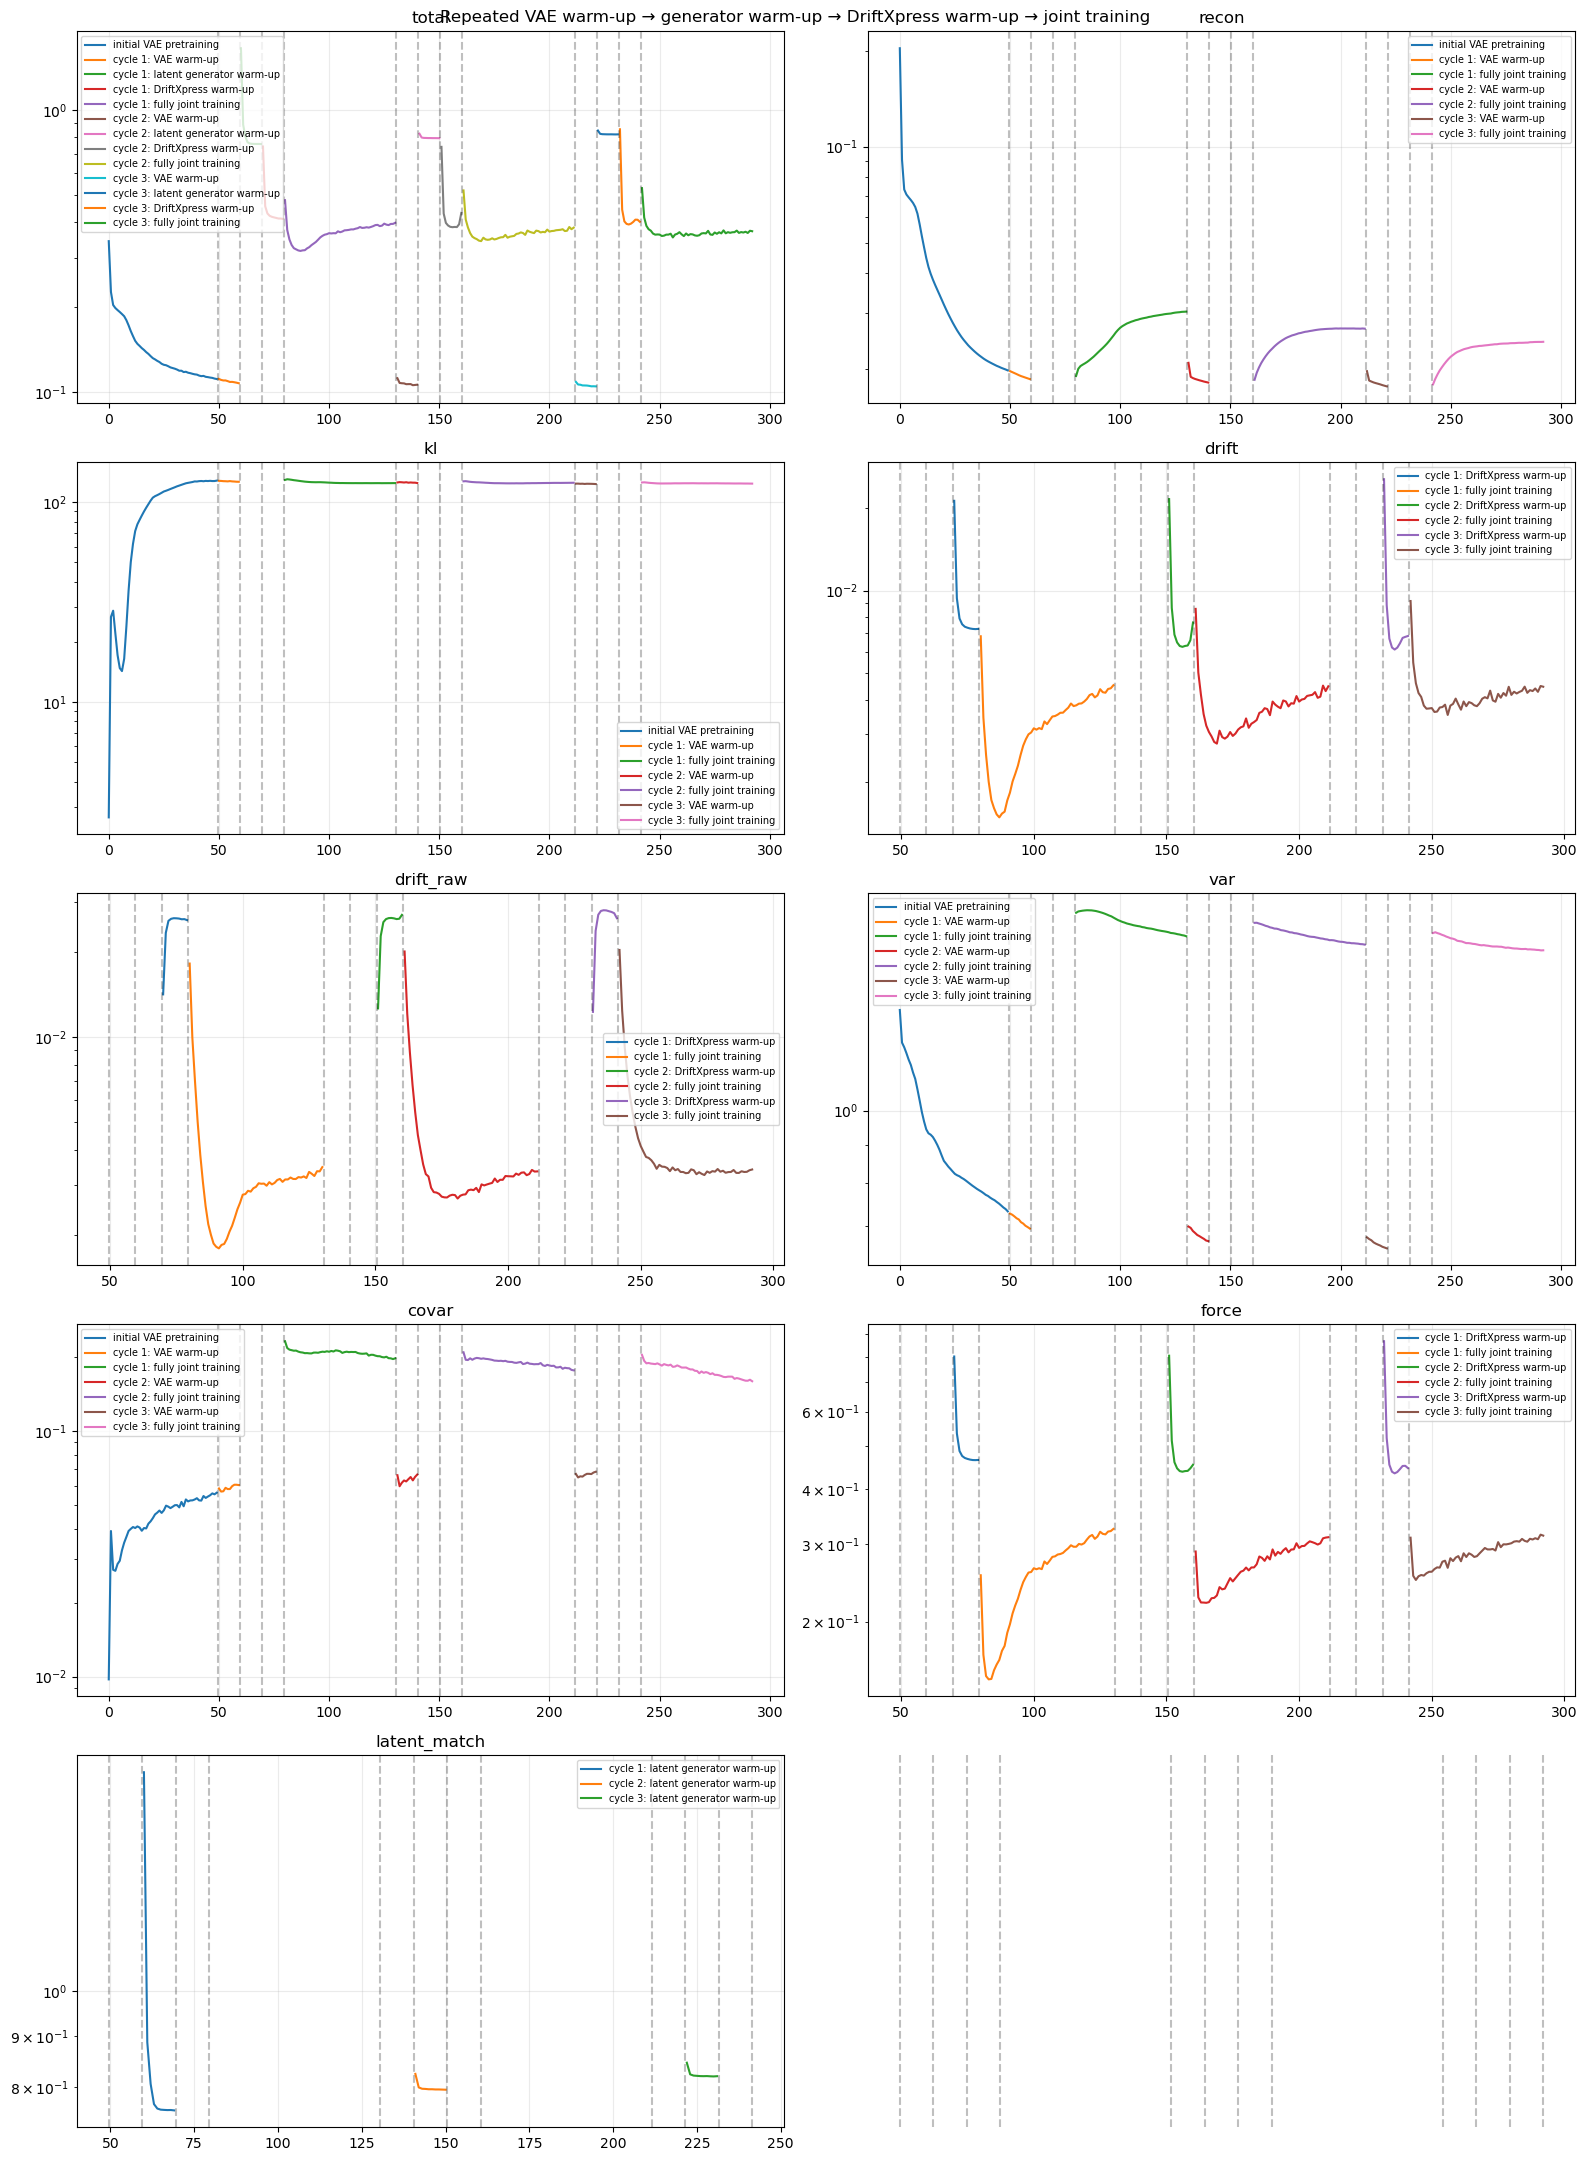

In [9]:
joint_history = {
    "total": losses,
    "recon": recon_losses,
    "kl": kl_losses,
    "drift": drift_losses,
    "drift_raw": drift_raw_losses,
    "var": var_losses,
    "covar": covar_losses,
    "force": average_V,
}


def plot_repeated_training_phases(phase_history):
    """Plot all VAE, generator, DriftXpress, and joint phases in order."""
    keys = ("total", "recon", "kl", "drift", "drift_raw", "var", "covar", "force", "latent_match")
    figure, axes = plt.subplots(5, 2, figsize=(16, 22), sharex=False)
    axes = axes.ravel()
    boundaries = []
    offset = 0

    for phase_name, history in phase_history:
        phase_length = len(history.get("total", []))
        boundaries.append((offset, offset + phase_length, phase_name))
        offset += phase_length

    for axis, key in zip(axes, keys):
        offset = 0
        plotted = False
        for phase_name, history in phase_history:
            values = np.asarray(history.get(key, []), dtype=float)
            if values.size:
                x_values = np.arange(offset, offset + values.size)
                axis.plot(x_values, values, label=phase_name)
                plotted = True
            offset += len(history.get("total", []))
        if plotted:
            axis.set_title(key)
            axis.set_yscale("log")
            axis.grid(alpha=0.25)
            axis.legend(fontsize=7)
        else:
            axis.axis("off")

    for _, end, _ in boundaries[:-1]:
        for axis in axes:
            axis.axvline(end - 0.5, color="black", linestyle="--", alpha=0.25)
    axes[-1].axis("off")
    figure.suptitle(
        "Repeated VAE warm-up → generator warm-up → DriftXpress warm-up → joint training"
    )
    figure.tight_layout()
    return figure, axes


fig, axes = plot_repeated_training_phases(phase_history)
plt.show()


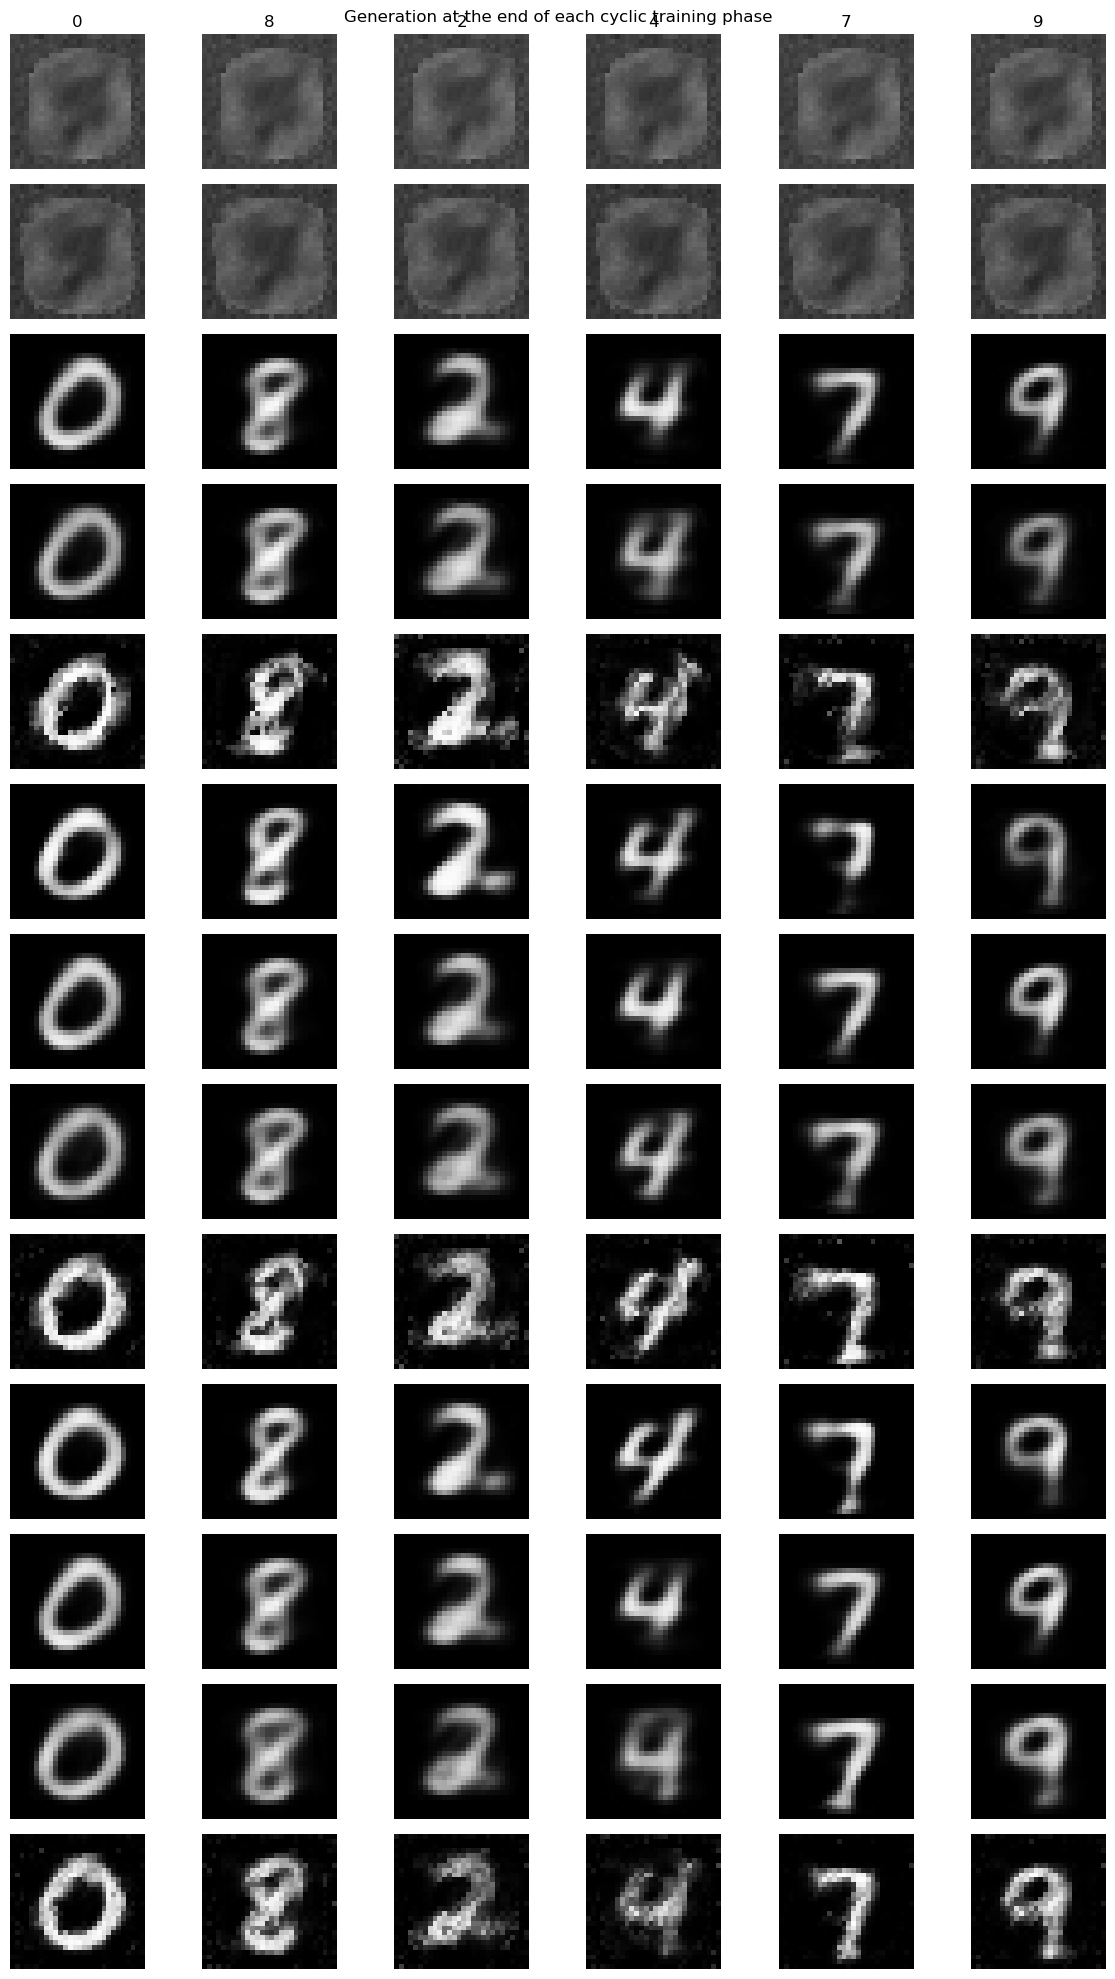

In [10]:
def plot_generation_evolution(generation_evolution):
    """Show fixed-noise generations at the end of every training phase."""
    if not generation_evolution:
        raise ValueError("generation_evolution is empty")

    n_rows = len(generation_evolution)
    n_cols = generation_evolution[0]["images"].shape[0]
    figure, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(2.0 * n_cols, 1.55 * n_rows),
        squeeze=False,
    )
    digits = CLASS_TO_DIGIT[generation_evolution[0]["class_ids"]]

    for row, record in enumerate(generation_evolution):
        for column in range(n_cols):
            axis = axes[row, column]
            axis.imshow(record["images"][column, 0], cmap="gray", vmin=0, vmax=1)
            axis.axis("off")
            if row == 0:
                axis.set_title(str(int(digits[column])))
        axes[row, 0].set_ylabel(
            record["stage"],
            rotation=0,
            ha="right",
            va="center",
            fontsize=8,
            labelpad=12,
        )

    figure.suptitle("Generation at the end of each cyclic training phase")
    figure.tight_layout()
    return figure, axes


fig_generation, axes_generation = plot_generation_evolution(generation_evolution)
plt.show()


In [11]:
import importlib
import src.eval as eval_utils

importlib.reload(eval_utils)

from src.eval import evaluate_latent_model

In [12]:
# One reusable post-training call: it collects real encoder means and
# conditional generated latents/images, then computes latent SWD/FID and class metrics.
post_eval = evaluate_latent_model(
    f_trained,
    test_loader,
    device=device,
    n_samples=2048,
    n_classes=NUM_CLASSES,
    class_to_label=CLASS_TO_DIGIT,
    include_mmd=False,
    include_fid=True,
)

samples = post_eval["samples"]
real_latents = samples["real_latents"]
generated_latents = samples["generated_latents"]
real_pixels = samples["real_images"]
generated_pixels = samples["generated_images"]
real_class_labels = samples["real_class_ids"]
generated_class_labels = samples["generated_class_ids"]
real_labels = samples["real_labels"]
generated_labels = samples["generated_labels"]
metrics = post_eval["metrics"]
latent_stats = post_eval["statistics"]

print("Latent-space metrics:")
for name, value in metrics.items():
    print(f"{name}: {value:.6f}")


Latent-space metrics:
sliced_wasserstein: 0.382927
fid: 13.782514
class_coverage: 1.000000
class_entropy: 0.999253


In [13]:
import sys
import inspect

project_root = r"C:\Users\mateo\Desktop\polymath-jr-drifting"

if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Remove stale src modules without restarting the kernel.
for name in list(sys.modules):
    if name == "src" or name.startswith("src."):
        del sys.modules[name]

import src.eval as eval_utils

print(eval_utils.__file__)
print(inspect.signature(eval_utils.evaluate_generation))

from src.eval import evaluate_latent_model, evaluate_generation

C:\Users\mateo\Desktop\polymath-jr-drifting\src\eval.py
(real_features: 'Any', generated_features: 'Any', generated_labels: 'Any | None' = None, n_classes: 'int | None' = None, coverage_min_count: 'int' = 1, random_state: 'int | None' = 0, n_projections: 'int' = 128, mmd_max_samples: 'int | None' = 2048, include_mmd: 'bool' = True, include_fid: 'bool' = True) -> 'dict[str, float]'


In [14]:
# This is the same compact metric interface in pixel space.
# Its FID is a pixel-space Fréchet distance; use evaluate_mnist_generation with a
# frozen evaluator when you specifically want learned MNIST-feature FID.
pixel_metrics = evaluate_generation(
    real_pixels,
    generated_pixels,
    generated_labels=generated_class_labels,
    n_classes=NUM_CLASSES,
    include_mmd=False,
)
print("Pixel-space metrics:")
for name, value in pixel_metrics.items():
    print(f"{name}: {value:.6f}")


Pixel-space metrics:
sliced_wasserstein: 0.093927
fid: 26.622004
class_coverage: 1.000000
class_entropy: 0.999253


In [15]:
print("Latent statistics:")
for name, value in latent_stats.items():
    print(f"{name}: {value:.6f}")


Latent statistics:
real_latent_mean: -0.060202
generated_latent_mean: -0.071670
real_latent_std: 0.812601
generated_latent_std: 0.431284
generated_to_real_std_ratio: 0.530745
real_total_correlation: 12.713060
generated_total_correlation: 30.675878


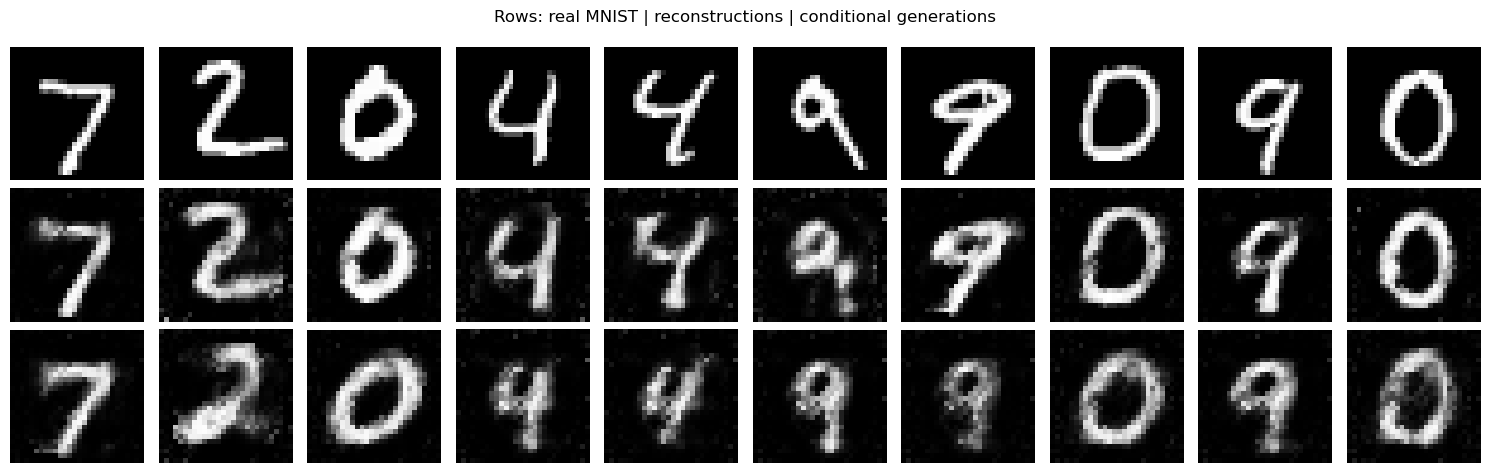

In [16]:
fig, axes = plot_conditional_mnist_results(
    f_trained,
    test_loader,
    device=device,
    samples=10,
    use_mean_for_reconstruction=True,
)
plt.show()


{'real_latent_mean': -0.06020224693864051, 'generated_latent_mean': -0.06548294303430247, 'real_latent_std': 0.8126007832204408, 'generated_latent_std': 0.515195486332332, 'generated_to_real_std_ratio': 0.6340081094809513, 'real_total_correlation': 12.713059688143613, 'generated_total_correlation': 19.07214537437752}


C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\mateo\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


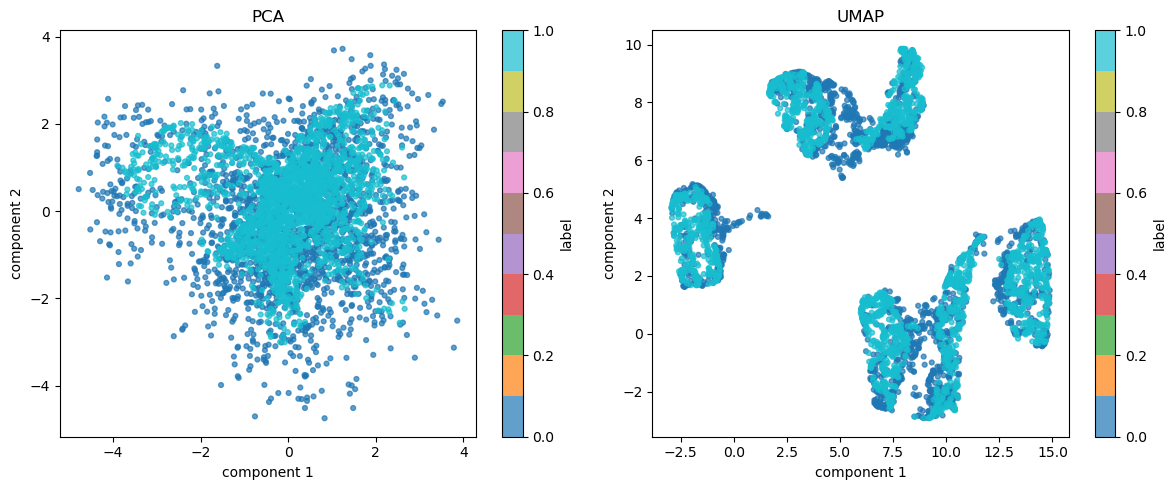

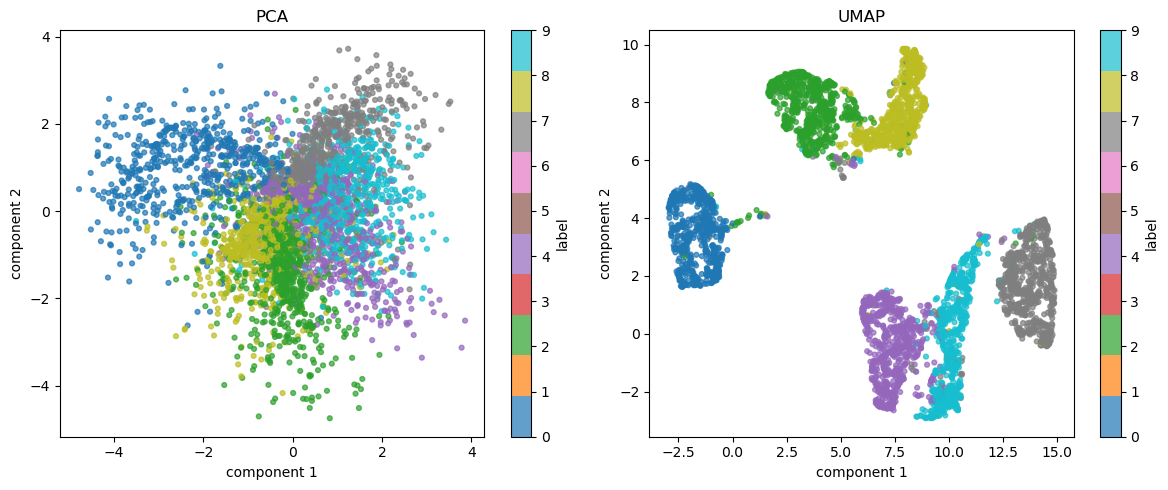

In [17]:
with torch.no_grad():
    generated_images_tensor = torch.as_tensor(
        generated_pixels, dtype=torch.float32, device=device
    )
    generated_reencoded = f_trained.encode_mu(generated_images_tensor).cpu().numpy()

reencoded_stats = latent_statistics(real_latents, generated_reencoded)
print(reencoded_stats)

plot_real_generated_projections(
    real_latents,
    generated_reencoded,
    real_labels=real_labels,
    generated_labels=generated_labels,
    methods=("pca", "umap"),
)
plt.show()

Within each cycle, the attraction summaries are precomputed once and reused for the complete generator and joint phases.

"
    "After the short VAE warm-up changes the encoder, the summaries are rebuilt once at the next cycle boundary so the following phases use the current latent coordinates.
